# Optimization II: Project 2 - Parts 1-6 Full - Abhiroop Kumar

---

## Tommy's Code for Q1 - Q3

---

## Part 1:

- The plan has 100 coach seats, 20 first class seats
- We have 365 days to sell tickets before flight departs, 1 or 0 ticket per day
- Coach can be priced at $300 (65% probability of sale), $325 (45%), or $350 (30%)
- First class at $425 (8%) or $500 (4%)
- If first class sells out, coach sale prob increases by 4pp regardless of price
- Each coach ticket holder shows up with 95% chance probability, each first class at 97%
- If more than 100 coach passengers show up, bump to first class at $50/person if seats available, otherwise pay voucher for another flight at $425/person
- No overbooking is possible for first class
- Discount rate is 1/(1 + 0.17/365)

Allow coach to be oversold by 5 seats, so max coach tickets sold can be 105

Find optimal pricing policy, so which coach price and first class price to charge each day to maximize expected discounted profit

In [5]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

choice_labels = [   #standardizing colors for future reference
    '$300C + $425F',
    '$300C + $500F',
    '$325C + $425F',
    '$325C + $500F',
    '$350C + $425F',
    '$350C + $500F',
    'No Sale + $425F',
    'No Sale + $500F'
]

cmap_standard = plt.cm.get_cmap('tab10', 8)

C:\Users\Abhiroop Kumar\AppData\Local\Temp\ipykernel_19420\1601617625.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_standard = plt.cm.get_cmap('tab10', 8)


In [6]:
T = 365
coach_seats = 100
first_class_seats = 20
overbooking_limit = 5
max_coach_tix_sold = coach_seats + overbooking_limit

In [7]:
V = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1)) #the 366x106x21 tensor dimension from class
U = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1), dtype=int) #stores choices from class

In [8]:
high_coach_price = 350
high_coach_prob = 0.30
med_coach_price = 325
med_coach_prob = 0.45
low_coach_price = 300
low_coach_prob = 0.65
high_first_class_price = 500
high_first_class_prob = 0.04
low_first_class_price = 425
low_first_class_prob = 0.08

choices = [
    (low_coach_price, low_coach_prob, low_first_class_price, low_first_class_prob),
    (low_coach_price, low_coach_prob, high_first_class_price, high_first_class_prob),
    (med_coach_price, med_coach_prob, low_first_class_price, low_first_class_prob),
    (med_coach_price, med_coach_prob, high_first_class_price, high_first_class_prob),
    (high_coach_price, high_coach_prob, low_first_class_price, low_first_class_prob),
    (high_coach_price, high_coach_prob, high_first_class_price, high_first_class_prob)
]

choices

[(300, 0.65, 425, 0.08),
 (300, 0.65, 500, 0.04),
 (325, 0.45, 425, 0.08),
 (325, 0.45, 500, 0.04),
 (350, 0.3, 425, 0.08),
 (350, 0.3, 500, 0.04)]

In [9]:
coach_show_up_prob = 0.95
first_class_show_up_prob = 0.97
bump_to_fc_cost = 50
bump_off_plane_cost = 425
discount = 1/(1+0.17/365)
first_class_sold_out_boost = 0.04

Terminal Condition:

Finding V[365, c, f] for all possible c, f combinations

In [10]:
for c in range(max_coach_tix_sold+1): #for every possible number of coach tickets sold
    for f in range(first_class_seats+1): #"" first class tickets sold
        cost_expected = 0
        p_coach = binom.pmf(range(c+1), c, coach_show_up_prob) #probabilities of 0, 1, ..., c coach passengers showing up
        p_first_class = binom.pmf(range(f+1), f, first_class_show_up_prob) #"" of f first class passengers showing up
        for i in range(c+1): #for every possible number of coach passengers that show up
            for j in range(f+1): #"" first class passengers that show up
                p_ij = p_coach[i] * p_first_class[j] #joint probability from class
                overbooked_coach = max(0, i - coach_seats) #overbooked coach passengers witout a coach seat
                first_class_empty_seats = max(0, first_class_seats - j) #empty first class seats
                bumped_to_first_class = min(overbooked_coach, first_class_empty_seats) #passengers bumped from coach to first class at $50/person
                bumped_off_plane = overbooked_coach - bumped_to_first_class #passengers given vouchers to new flights at $425/person
                cost = bumped_to_first_class * bump_to_fc_cost + bumped_off_plane * bump_off_plane_cost #total cost of overbooking in one scenario
                cost_expected += p_ij * cost #expected cost of overbooking across every scenario
        V[T, c, f] = -cost_expected #trying to maximize profit, minimize costs

In [11]:
# V[365, 0, 0] #at last day, sold no coach or first class tix, expected cost
# V[365, 100, 20] #sold out, expected cost
# V[365, 105, 20] #overbooked coach by 5, sold out, expected cost is nonzero
V[365, 105, 15] #overbooked coach by 5, first class not sold out, expected cost is lower than previous check

np.float64(-37.52470504591379)

Bellman equation:

Loop backwards in time to find the value function at every possible state

In [12]:
for t in reversed(range(T)): #loop backwards in time, starting at 364 since terminal condition covers 365
    for c in range(max_coach_tix_sold+1): #can sell 105 tix
        for f in range(first_class_seats+1): #can't overbook first class
            coach_full = (c == max_coach_tix_sold) #if c = 105, coach is full, can't sell more
            first_class_full = (f == first_class_seats) #if f = 20, first class is full, can't sell more

            if coach_full and first_class_full:
                V[t, c, f] = discount * V[t+1, c, f] #no reward today because we can't sell any more tickets, discounted future value
                U[t, c, f] = 0 #can't sell
                continue

            best_profit = -np.inf 
            best_price_choice = 0

            for index, (coach_price, coach_prob, first_class_price, first_class_prob) in enumerate(choices): #for each of the 6 price combos
                prob_sell_coach = 0 if coach_full else coach_prob
                prob_sell_first_class = 0 if first_class_full else first_class_prob

                if first_class_full and not coach_full:
                    prob_sell_coach = min(1, prob_sell_coach + first_class_sold_out_boost) #increase of 4% chance of selling a coach ticket if first class is sold out

                coach_next_state = min(c+1, max_coach_tix_sold) #if we sell a coach ticket, next state is c+1, cannot > 105
                first_class_next_state = min(f+1, first_class_seats) #if we sell a first class ticket, next state is f+1, cannot > 20

                today_revenue = prob_sell_coach * coach_price + prob_sell_first_class * first_class_price #expected revenue from selling tickets today
                future_revenue = (
                    (1-prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, c, f] + #sold no tickets
                    (prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, coach_next_state, f] + #sold coach ticket only
                    (1-prob_sell_coach) * (prob_sell_first_class) * V[t+1, c, first_class_next_state ] + #sold first class ticket only
                    (prob_sell_coach) * (prob_sell_first_class) * V[t+1, coach_next_state, first_class_next_state] #sold both tickets
                )

                profit = today_revenue + discount * future_revenue

                if profit > best_profit:
                    best_profit = profit
                    best_price_choice = index + 1

            V[t, c, f] = best_profit
            U[t, c, f] = best_price_choice

In [13]:
round(V[0, 0, 0], 2) #expected profit if we start with no tickets sold on day 0 and follow optimal policy

np.float64(41909.75)

C:\Users\Abhiroop Kumar\AppData\Local\Temp\ipykernel_19420\3609307292.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 6)


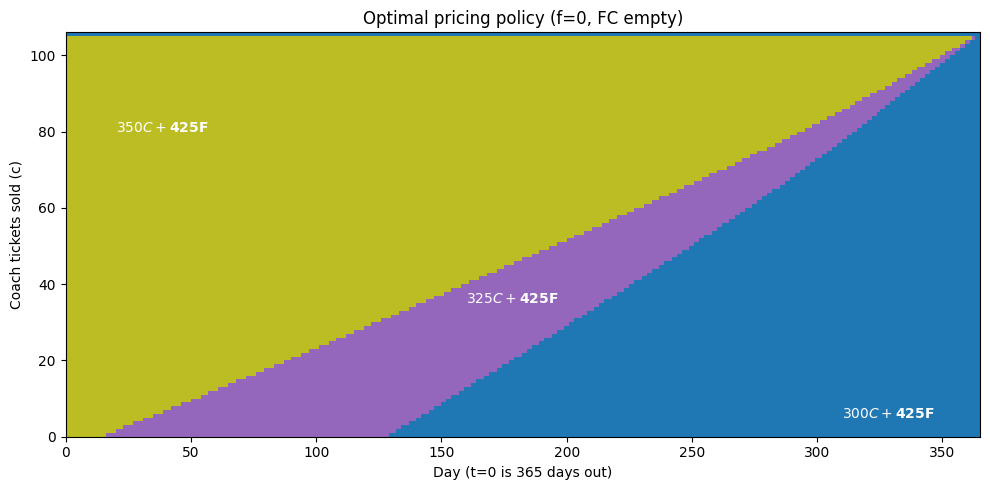

In [14]:
import matplotlib.pyplot as plt

labels = [f"${cp}C+${fp}F" for cp, _, fp, _ in choices]
cmap = plt.cm.get_cmap('tab10', 6)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.pcolormesh(U[:T, :, 0].T, cmap=cmap, vmin=0.5, vmax=6.5)

# Direct labels — (t, c) coordinates chosen to land inside each region
ax.text(20,  80, '$350C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(160, 35, '$325C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(310,  5, '$300C + $425F', fontsize=10, color='white', fontweight='bold')

ax.set_xlabel('Day (t=0 is 365 days out)')
ax.set_ylabel('Coach tickets sold (c)')
ax.set_title('Optimal pricing policy (f=0, FC empty)')
plt.tight_layout()
plt.show()

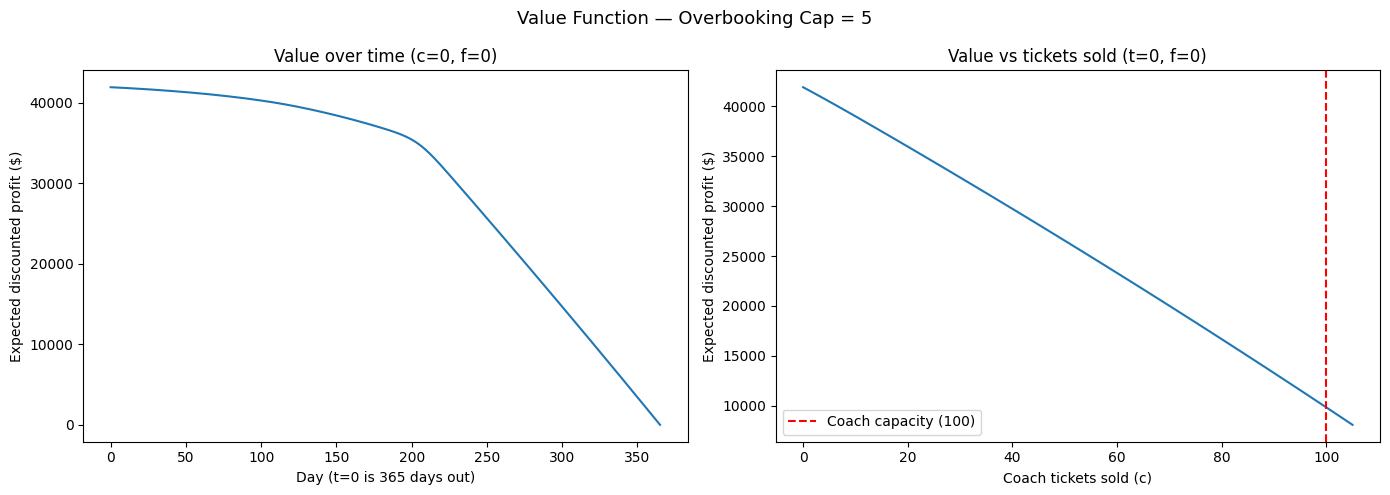

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: value function over time (no tickets sold yet)
axes[0].plot(range(T+1), V[:, 0, 0])
axes[0].set_xlabel('Day (t=0 is 365 days out)')
axes[0].set_ylabel('Expected discounted profit ($)')
axes[0].set_title('Value over time (c=0, f=0)')

# Right: value function as coach tickets sold increases (day 0)
axes[1].plot(range(max_coach_tix_sold+1), V[0, :, 0])
axes[1].axvline(x=coach_seats, color='red', linestyle='--', label='Coach capacity (100)')
axes[1].set_xlabel('Coach tickets sold (c)')
axes[1].set_ylabel('Expected discounted profit ($)')
axes[1].set_title('Value vs tickets sold (t=0, f=0)')
axes[1].legend()

plt.suptitle('Value Function — Overbooking Cap = 5', fontsize=13)
plt.tight_layout()
plt.show()

---

## Part 2: 

Now repeating Part 1 but allowing ourselves to overbook coach by 6, 7, 8, ..., 20 seats to find which overbooking policy leads to the largest profits

In [16]:
def simulate_policy(overbooking_limit):
    max_coach_tix_sold = coach_seats + overbooking_limit

    V = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1)) #the 366x106x21 tensor dimension from class
    U = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1), dtype=int) #stores choices from class

    #terminal condition:
    for c in range(max_coach_tix_sold+1): #for every possible number of coach tickets sold
        for f in range(first_class_seats+1): #"" first class tickets sold
            cost_expected = 0
            p_coach = binom.pmf(range(c+1), c, coach_show_up_prob) #probabilities of 0, 1, ..., c coach passengers showing up
            p_first_class = binom.pmf(range(f+1), f, first_class_show_up_prob) #"" of f first class passengers showing up
            for i in range(c+1): #for every possible number of coach passengers that show up
                for j in range(f+1): #"" first class passengers that show up
                    p_ij = p_coach[i] * p_first_class[j] #joint probability from class
                    overbooked_coach = max(0, i - coach_seats) #overbooked coach passengers witout a coach seat
                    first_class_empty_seats = max(0, first_class_seats - j) #empty first class seats
                    bumped_to_first_class = min(overbooked_coach, first_class_empty_seats) #passengers bumped from coach to first class at $50/person
                    bumped_off_plane = overbooked_coach - bumped_to_first_class #passengers given vouchers to new flights at $425/person
                    cost = bumped_to_first_class * bump_to_fc_cost + bumped_off_plane * bump_off_plane_cost #total cost of overbooking in one scenario
                    cost_expected += p_ij * cost #expected cost of overbooking across every scenario
            V[T, c, f] = -cost_expected #trying to maximize profit, minimize costs

    #bellman equation
    for t in reversed(range(T)): #loop backwards in time, starting at 364 since terminal condition covers 365
        for c in range(max_coach_tix_sold+1): #can sell 105 tix
            for f in range(first_class_seats+1): #can't overbook first class
                coach_full = (c == max_coach_tix_sold) #if c = 105, coach is full, can't sell more
                first_class_full = (f == first_class_seats) #if f = 20, first class is full, can't sell more

                if coach_full and first_class_full:
                    V[t, c, f] = discount * V[t+1, c, f] #no reward today because we can't sell any more tickets, discounted future value
                    U[t, c, f] = 0 #can't sell
                    continue

                best_profit = -np.inf 
                best_price_choice = 0

                for index, (coach_price, coach_prob, first_class_price, first_class_prob) in enumerate(choices): #for each of the 6 price combos
                    prob_sell_coach = 0 if coach_full else coach_prob
                    prob_sell_first_class = 0 if first_class_full else first_class_prob

                    if first_class_full and not coach_full:
                        prob_sell_coach = min(1, prob_sell_coach + first_class_sold_out_boost) #increase of 4% chance of selling a coach ticket if first class is sold out

                    coach_next_state = min(c+1, max_coach_tix_sold) #if we sell a coach ticket, next state is c+1, cannot > 105
                    first_class_next_state = min(f+1, first_class_seats) #if we sell a first class ticket, next state is f+1, cannot > 20

                    today_revenue = prob_sell_coach * coach_price + prob_sell_first_class * first_class_price #expected revenue from selling tickets today
                    future_revenue = (
                        (1-prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, c, f] + #sold no tickets
                        (prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, coach_next_state, f] + #sold coach ticket only
                        (1-prob_sell_coach) * (prob_sell_first_class) * V[t+1, c, first_class_next_state ] + #sold first class ticket only
                        (prob_sell_coach) * (prob_sell_first_class) * V[t+1, coach_next_state, first_class_next_state] #sold both tickets
                    )

                    profit = today_revenue + discount * future_revenue

                    if profit > best_profit:
                        best_profit = profit
                        best_price_choice = index + 1

                V[t, c, f] = best_profit
                U[t, c, f] = best_price_choice

    return V, U, round(V[0, 0, 0], 2)

In [17]:
simulate_policy(5) #checking for answer we found earlier: 41909.75

(array([[[ 4.19097485e+04,  4.15793070e+04,  4.12437377e+04, ...,
           3.49116616e+04,  3.44650101e+04,  3.40156879e+04],
         [ 4.16271896e+04,  4.12965480e+04,  4.09607759e+04, ...,
           3.46113655e+04,  3.41637817e+04,  3.37136298e+04],
         [ 4.13424046e+04,  4.10115685e+04,  4.06756004e+04, ...,
           3.43101662e+04,  3.38617488e+04,  3.34108518e+04],
         ...,
         [ 8.79549530e+03,  8.46311184e+03,  8.12556736e+03, ...,
           1.47868866e+03,  9.89926822e+02,  4.95619355e+02],
         [ 8.44641702e+03,  8.11403356e+03,  7.77648909e+03, ...,
           1.12960825e+03,  6.40830593e+02,  1.46413724e+02],
         [ 8.09679680e+03,  7.76441334e+03,  7.42686886e+03, ...,
           7.79987559e+02,  2.91204933e+02, -2.03270270e+02]],
 
        [[ 4.19012191e+04,  4.15710996e+04,  4.12357855e+04, ...,
           3.49107689e+04,  3.44643068e+04,  3.40151369e+04],
         [ 4.16192146e+04,  4.12888941e+04,  4.09533760e+04, ...,
           3.46106516

In [18]:
for i in range(5, 21): #from 5 to 20, the range of overbooking limits to check
    V, U, expected_profit = simulate_policy(i) #grab the expected profit for each overbooking limit
    print(f"Overbooking limit: {i}, Expected profit: {expected_profit}")

Overbooking limit: 5, Expected profit: 41909.75
Overbooking limit: 6, Expected profit: 42039.02
Overbooking limit: 7, Expected profit: 42117.95
Overbooking limit: 8, Expected profit: 42157.77
Overbooking limit: 9, Expected profit: 42171.35
Overbooking limit: 10, Expected profit: 42169.24
Overbooking limit: 11, Expected profit: 42158.86
Overbooking limit: 12, Expected profit: 42144.91
Overbooking limit: 13, Expected profit: 42130.13
Overbooking limit: 14, Expected profit: 42115.88
Overbooking limit: 15, Expected profit: 42102.78
Overbooking limit: 16, Expected profit: 42091.04
Overbooking limit: 17, Expected profit: 42080.72
Overbooking limit: 18, Expected profit: 42071.78
Overbooking limit: 19, Expected profit: 42064.15
Overbooking limit: 20, Expected profit: 42057.69


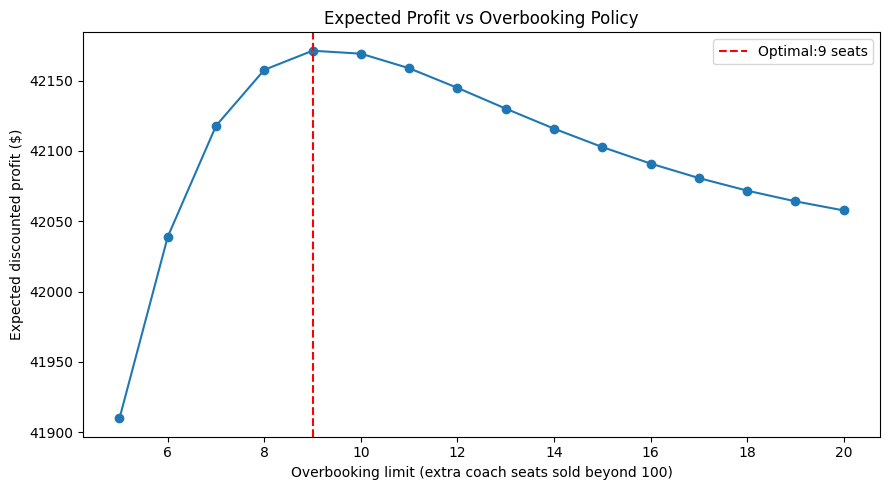

Optimal overbooking limit: 9 seats
Optimal expected profit: $42,171.35


In [19]:
overbooking_range = range(5, 21)
profits = [simulate_policy(ob)[2] for ob in overbooking_range]

plt.figure(figsize=(9, 5))
plt.plot(overbooking_range, profits, marker='o')
plt.axvline(x=overbooking_range[profits.index(max(profits))], color='red', linestyle='--', label=f'Optimal:{overbooking_range[profits.index(max(profits))]} seats')
plt.xlabel('Overbooking limit (extra coach seats sold beyond 100)')
plt.ylabel('Expected discounted profit ($)')
plt.title('Expected Profit vs Overbooking Policy')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal overbooking limit: {overbooking_range[profits.index(max(profits))]} seats")
print(f"Optimal expected profit: ${max(profits):,.2f}")

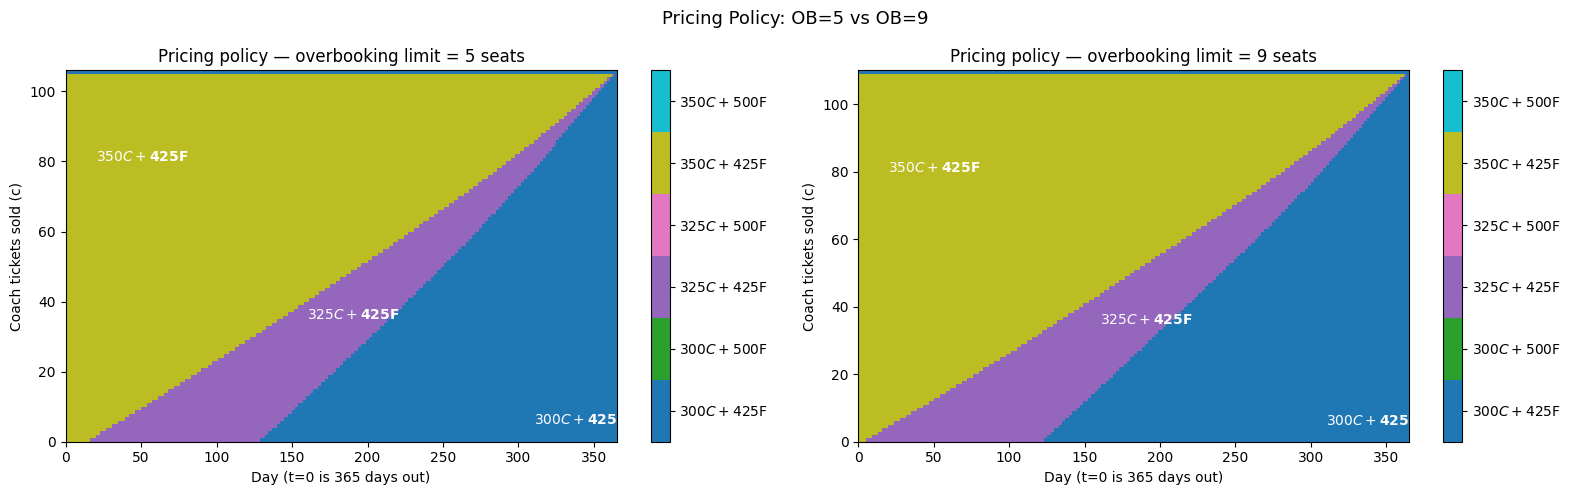

In [20]:
optimal_ob = 9

V5, U5, _ = simulate_policy(5)
V_opt, U_opt, _ = simulate_policy(optimal_ob)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, U_plot, ob in zip(axes, [U5, U_opt], [5, optimal_ob]):
    im = ax.pcolormesh(U_plot[:T, :, 0].T, cmap=cmap, vmin=0.5, vmax=6.5)
    cbar = fig.colorbar(im, ax=ax, ticks=range(1, 7))
    cbar.ax.set_yticklabels(labels)
    ax.text(20,  80, '$350C + $425F', fontsize=10, color='white', fontweight='bold')
    ax.text(160, 35, '$325C + $425F', fontsize=10, color='white', fontweight='bold')
    ax.text(310,  5, '$300C + $425F', fontsize=10, color='white', fontweight='bold')
    ax.set_xlabel('Day (t=0 is 365 days out)')
    ax.set_ylabel('Coach tickets sold (c)')
    ax.set_title(f'Pricing policy — overbooking limit = {ob} seats')

plt.suptitle('Pricing Policy: OB=5 vs OB=9', fontsize=13)
plt.tight_layout()
plt.show()

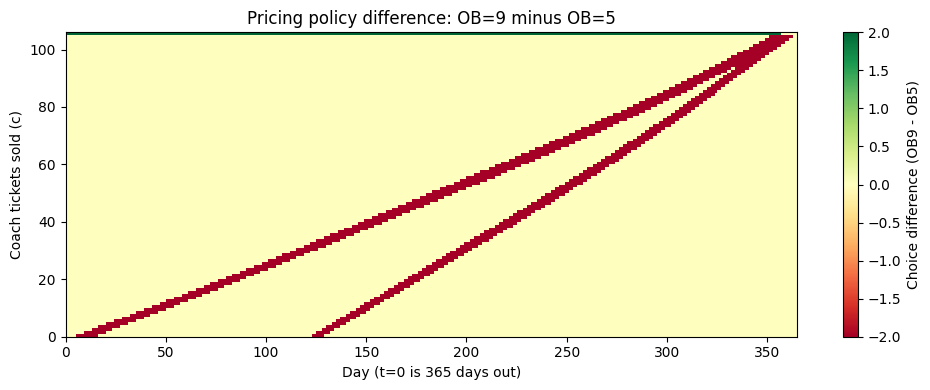

In [21]:
min_c = min(U5.shape[1], U_opt.shape[1])

diff = U_opt[:T, :min_c, 0] - U5[:T, :min_c, 0]

plt.figure(figsize=(10, 4))
plt.pcolormesh(diff.T, cmap='RdYlGn', vmin=-2, vmax=2)
plt.colorbar(label='Choice difference (OB9 - OB5)')
plt.xlabel('Day (t=0 is 365 days out)')
plt.ylabel('Coach tickets sold (c)')
plt.title('Pricing policy difference: OB=9 minus OB=5')
plt.tight_layout()
plt.show()

Interpretation: The yellow shaded regions show where both policies (allowing up to 5, 9 overbooked coach seats) choose the same price combination to offer. The red shaded regions, ending up as two diagonal lines, show where the two policies differ. These are indicating slightly different pricing decisions, which end up as the boundaries in the previous graph from $350 and $325 pricing regions. So the new optimal overbooking policy at 9 seats overbooked chooses a lower coach price at these boundary states. With 4 more tickets to sell, the new policy is less scarce at these red shaded states, so it is optimal to drop to the medium price a little longer.

The optimal overbooking policy comes almost entirely from seeling 4 more tickets, not necessarily repricing. The two policies (5, 9 overbooked coach seats) are pretty identical in how they price day to day. 

---

## Part 3: 

We now have the option to sell no coach tickets on a day if we want. So now, there are 4 choices for coach: LP, MP, HP, no sale.

Airline will never sell more than 130 seats in coach.

In [22]:
T = 365
coach_seats = 100
first_class_seats = 20
overbooking_limit = 30
max_coach_tix_sold = coach_seats + overbooking_limit
max_coach_tix_sold #check

130

In [23]:
V = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1)) #the 366x131x21 tensor dimension now being able to book up to 30 extra coach seats
U = np.zeros((T+1, max_coach_tix_sold+1, first_class_seats+1), dtype=int) #stores choices from class

In [24]:
V.shape

(366, 131, 21)

In [25]:
high_coach_price = 350
high_coach_prob = 0.30
med_coach_price = 325
med_coach_prob = 0.45
low_coach_price = 300
low_coach_prob = 0.65
no_coach_price = 0
no_coach_prob = 0
high_first_class_price = 500
high_first_class_prob = 0.04
low_first_class_price = 425
low_first_class_prob = 0.08

choices = [
    (low_coach_price, low_coach_prob, low_first_class_price, low_first_class_prob),
    (low_coach_price, low_coach_prob, high_first_class_price, high_first_class_prob),
    (med_coach_price, med_coach_prob, low_first_class_price, low_first_class_prob),
    (med_coach_price, med_coach_prob, high_first_class_price, high_first_class_prob),
    (high_coach_price, high_coach_prob, low_first_class_price, low_first_class_prob),
    (high_coach_price, high_coach_prob, high_first_class_price, high_first_class_prob),
    (no_coach_price, no_coach_prob, low_first_class_price, low_first_class_prob),
    (no_coach_price, no_coach_prob, high_first_class_price, high_first_class_prob)
]

choices

[(300, 0.65, 425, 0.08),
 (300, 0.65, 500, 0.04),
 (325, 0.45, 425, 0.08),
 (325, 0.45, 500, 0.04),
 (350, 0.3, 425, 0.08),
 (350, 0.3, 500, 0.04),
 (0, 0, 425, 0.08),
 (0, 0, 500, 0.04)]

In [26]:
coach_show_up_prob = 0.95
first_class_show_up_prob = 0.97
bump_to_fc_cost = 50
bump_off_plane_cost = 425
discount = 1/(1+0.17/365)
first_class_sold_out_boost = 0.04

Terminal Condition copy and pasted from above

In [27]:
for c in range(max_coach_tix_sold+1): #for every possible number of coach tickets sold
    for f in range(first_class_seats+1): #"" first class tickets sold
        cost_expected = 0
        p_coach = binom.pmf(range(c+1), c, coach_show_up_prob) #probabilities of 0, 1, ..., c coach passengers showing up
        p_first_class = binom.pmf(range(f+1), f, first_class_show_up_prob) #"" of f first class passengers showing up
        for i in range(c+1): #for every possible number of coach passengers that show up
            for j in range(f+1): #"" first class passengers that show up
                p_ij = p_coach[i] * p_first_class[j] #joint probability from class
                overbooked_coach = max(0, i - coach_seats) #overbooked coach passengers witout a coach seat
                first_class_empty_seats = max(0, first_class_seats - j) #empty first class seats
                bumped_to_first_class = min(overbooked_coach, first_class_empty_seats) #passengers bumped from coach to first class at $50/person
                bumped_off_plane = overbooked_coach - bumped_to_first_class #passengers given vouchers to new flights at $425/person
                cost = bumped_to_first_class * bump_to_fc_cost + bumped_off_plane * bump_off_plane_cost #total cost of overbooking in one scenario
                cost_expected += p_ij * cost #expected cost of overbooking across every scenario
        V[T, c, f] = -cost_expected #trying to maximize profit, minimize costs

Bellman copy and pasted from above

In [28]:
for t in reversed(range(T)): #loop backwards in time, starting at 364 since terminal condition covers 365
    for c in range(max_coach_tix_sold+1): #can sell 105 tix
        for f in range(first_class_seats+1): #can't overbook first class
            coach_full = (c == max_coach_tix_sold) #if c = 105, coach is full, can't sell more
            first_class_full = (f == first_class_seats) #if f = 20, first class is full, can't sell more

            if coach_full and first_class_full:
                V[t, c, f] = discount * V[t+1, c, f] #no reward today because we can't sell any more tickets, discounted future value
                U[t, c, f] = 0 #can't sell
                continue

            best_profit = -np.inf 
            best_price_choice = 0

            for index, (coach_price, coach_prob, first_class_price, first_class_prob) in enumerate(choices): #for each of the 6 price combos
                prob_sell_coach = 0 if coach_full else coach_prob
                prob_sell_first_class = 0 if first_class_full else first_class_prob

                if first_class_full and not coach_full and coach_prob > 0:
                    prob_sell_coach = min(1, prob_sell_coach + first_class_sold_out_boost) #increase of 4% chance of selling a coach ticket if first class is sold out

                coach_next_state = min(c+1, max_coach_tix_sold) #if we sell a coach ticket, next state is c+1, cannot > 105
                first_class_next_state = min(f+1, first_class_seats) #if we sell a first class ticket, next state is f+1, cannot > 20

                today_revenue = prob_sell_coach * coach_price + prob_sell_first_class * first_class_price #expected revenue from selling tickets today
                future_revenue = (
                    (1-prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, c, f] + #sold no tickets
                    (prob_sell_coach) * (1-prob_sell_first_class) * V[t+1, coach_next_state, f] + #sold coach ticket only
                    (1-prob_sell_coach) * (prob_sell_first_class) * V[t+1, c, first_class_next_state ] + #sold first class ticket only
                    (prob_sell_coach) * (prob_sell_first_class) * V[t+1, coach_next_state, first_class_next_state] #sold both tickets
                )

                profit = today_revenue + discount * future_revenue

                if profit > best_profit:
                    best_profit = profit
                    best_price_choice = index + 1

            V[t, c, f] = best_profit
            U[t, c, f] = best_price_choice

In [29]:
round(V[0, 0, 0], 2) #expected profit if we start with no tickets sold on day 0 and follow optimal policy

np.float64(42177.14)

% of states where no-sale is chosen: 7.0%


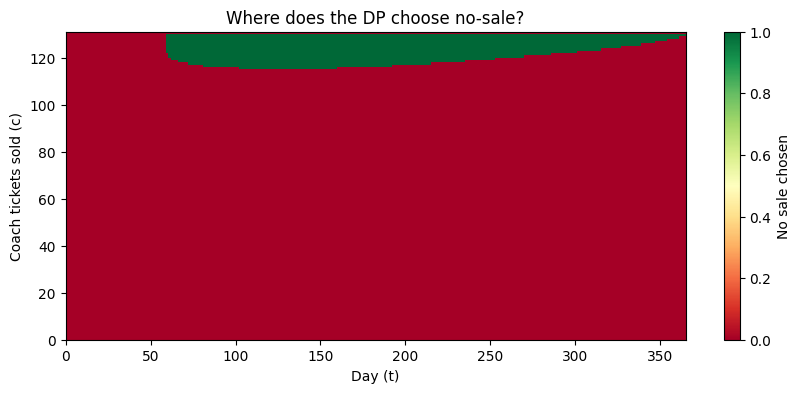

In [30]:
no_sale_mask = (U[:T, :, 0] == 7) | (U[:T, :, 0] == 8)
print(f"% of states where no-sale is chosen: {no_sale_mask.mean()*100:.1f}%")

plt.figure(figsize=(10, 4))
plt.pcolormesh(no_sale_mask.T, cmap='RdYlGn')
plt.xlabel('Day (t)')
plt.ylabel('Coach tickets sold (c)')
plt.title('Where does the DP choose no-sale?')
plt.colorbar(label='No sale chosen')
plt.show()

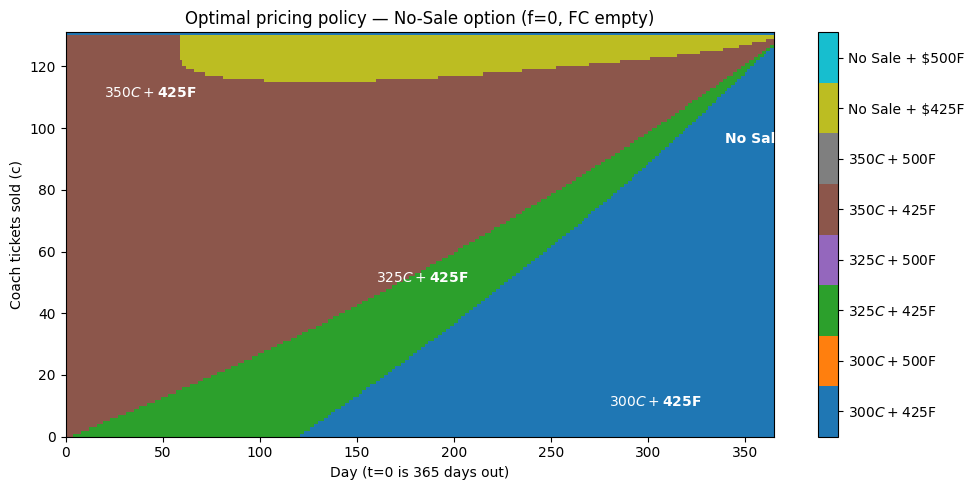

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.pcolormesh(U[:T, :, 0].T, cmap=cmap_standard, vmin=0.5, vmax=8.5)
cbar = fig.colorbar(im, ax=ax, ticks=range(1, 9))
cbar.ax.set_yticklabels(choice_labels)
ax.set_xlabel('Day (t=0 is 365 days out)')
ax.set_ylabel('Coach tickets sold (c)')
ax.set_title('Optimal pricing policy — No-Sale option (f=0, FC empty)')

# direct labels — adjust coordinates after seeing the plot
ax.text(20,  110, '$350C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(160,  50, '$325C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(280,  10, '$300C + $425F', fontsize=10, color='white', fontweight='bold')
ax.text(340,  95, 'No Sale',        fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

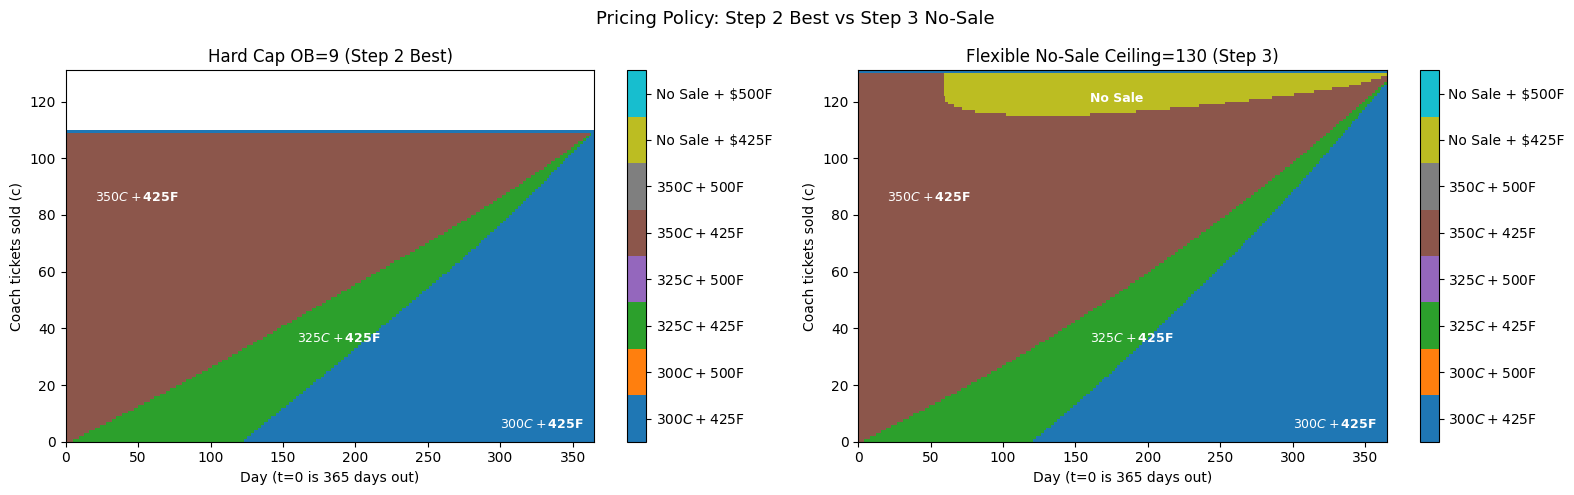

In [32]:
V_ob9, U_ob9, _ = simulate_policy(9)

# Match both panels to the same y-height (Step 3 max coach tickets sold),
# but leave OB=9 uncolored above its true ceiling (109).
target_height = U[:T, :, 0].shape[1]
left_height = U_ob9[:T, :, 0].shape[1]

U_ob9_padded = np.full((T, target_height), np.nan)
U_ob9_padded[:, :left_height] = U_ob9[:T, :, 0]

cmap_compare = cmap_standard.copy()
cmap_compare.set_bad(color='white')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, U_plot, title in zip(
    axes,
    [U_ob9_padded, U[:T, :, 0]],
    ['Hard Cap OB=9 (Step 2 Best)', 'Flexible No-Sale Ceiling=130 (Step 3)']
):
    im = ax.pcolormesh(U_plot.T, cmap=cmap_compare, vmin=0.5, vmax=8.5)
    cbar = fig.colorbar(im, ax=ax, ticks=range(1, 9))
    cbar.ax.set_yticklabels(choice_labels)
    ax.text(20, 85, '$350C + $425F', fontsize=9, color='white', fontweight='bold')
    ax.text(160, 35, '$325C + $425F', fontsize=9, color='white', fontweight='bold')
    ax.text(300, 5, '$300C + $425F', fontsize=9, color='white', fontweight='bold')
    ax.set_xlabel('Day (t=0 is 365 days out)')
    ax.set_ylabel('Coach tickets sold (c)')
    ax.set_ylim(0, target_height)
    ax.set_title(title)

# add no-sale label only on step 3 plot (second axis)
axes[1].text(160, 120, 'No Sale', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Pricing Policy: Step 2 Best vs Step 3 No-Sale', fontsize=13)
plt.tight_layout()
plt.show()

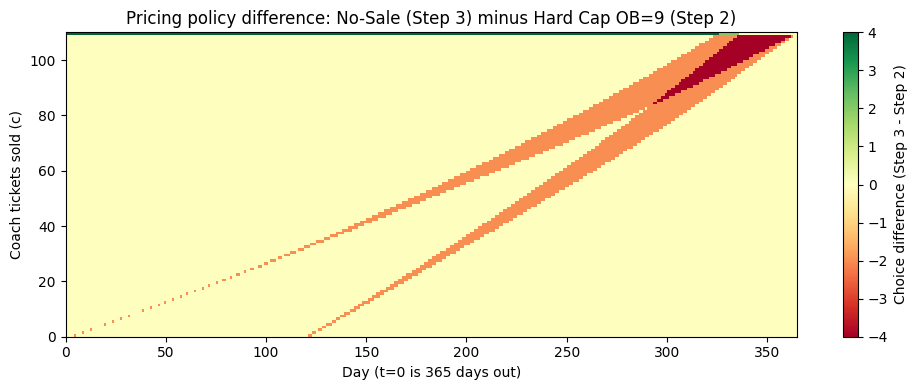

In [33]:
min_c = min(U_ob9.shape[1], U.shape[1])
diff = U[:T, :min_c, 0] - U_ob9[:T, :min_c, 0]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(diff.T, cmap='RdYlGn', vmin=-4, vmax=4)
plt.colorbar(im, label='Choice difference (Step 3 - Step 2)')
ax.set_xlabel('Day (t=0 is 365 days out)')
ax.set_ylabel('Coach tickets sold (c)')
ax.set_title('Pricing policy difference: No-Sale (Step 3) minus Hard Cap OB=9 (Step 2)')
plt.tight_layout()
plt.show()

Interpretation: Yellow still remains the unchanged policies when comparing Part 3 and 2's price combinations. Still in most states, the no-sale option for Part 3 doesn't change anything, where the dynamic program sells at the same price as before. 

There's now 2 different price combinations that Part 3 differs from than Part 2. The orange difference is the same shift we saw comparing Part 1 and Part 2. Part 3 chooses a slightly lower coach price than Part 2 to avoid overbooking costs.

The new region is the top right, red shaded area. So now, as you approach takeoff with already many tickets sold in both coach and first class, Part 3 is choosing either a lower or no sale option to avoid overbooking costs incurred in Part 2.

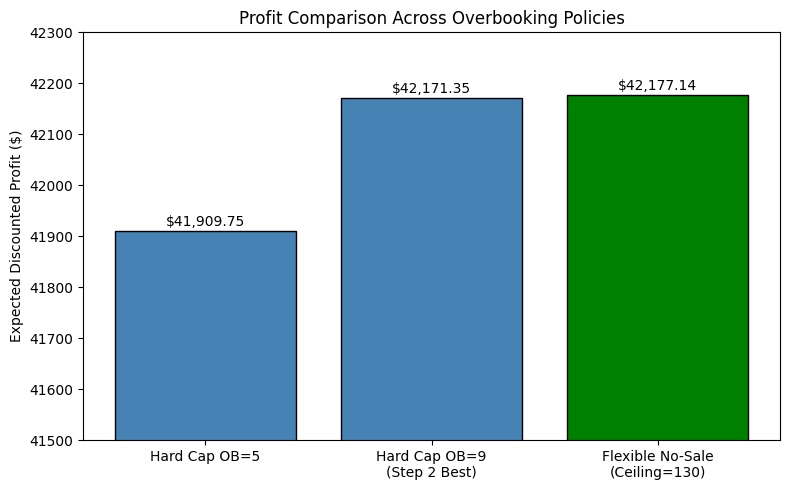

In [34]:
policies = ['Hard Cap OB=5', 'Hard Cap OB=9\n(Step 2 Best)', 'Flexible No-Sale\n(Ceiling=130)']
profits_3 = [41909.75, 42171.35, 42177.14]

plt.figure(figsize=(8, 5))
bars = plt.bar(policies, profits_3, color=['steelblue', 'steelblue', 'green'], edgecolor='black')
plt.ylim(41500, 42300)
plt.ylabel('Expected Discounted Profit ($)')
plt.title('Profit Comparison Across Overbooking Policies')
for bar, profit in zip(bars, profits_3):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'${profit:,.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

- Overbooking policy (5): $41,909.75
- Overbooking policy (9): $42,171.35
- No-sale option, overbooking policy (30): $42,177.14

---

## Part 4: Sensitivity Analysis on Sale Probabilities

- With ticket prices fixed, we perturb each sale probability slightly and observe how expected profit changes.
- We test +/- 1, 3, and 5 percentage point shifts on each of the 5 base probabilities, holding all others fixed.
- We use the Part 3 setup (OB=30, no-sale option) as our baseline.

In [54]:
# ---- Replicate Part 3 baseline parameters ----
T = 365
coach_seats = 100
first_class_seats = 20
overbooking_limit = 30
max_coach_tix_sold = coach_seats + overbooking_limit  # 130
 
coach_show_up_prob    = 0.95
first_class_show_up_prob = 0.97
bump_to_fc_cost       = 50
bump_off_plane_cost   = 425
discount              = 1 / (1 + 0.17 / 365)
first_class_sold_out_boost = 0.04
 
high_coach_price  = 350;  high_coach_prob  = 0.30
med_coach_price   = 325;  med_coach_prob   = 0.45
low_coach_price   = 300;  low_coach_prob   = 0.65
no_coach_price    = 0;    no_coach_prob    = 0.00
high_fc_price     = 500;  high_fc_prob     = 0.04
low_fc_price      = 425;  low_fc_prob      = 0.08
 
BASE_CHOICES = [
    (low_coach_price,  low_coach_prob,  low_fc_price,  low_fc_prob),
    (low_coach_price,  low_coach_prob,  high_fc_price, high_fc_prob),
    (med_coach_price,  med_coach_prob,  low_fc_price,  low_fc_prob),
    (med_coach_price,  med_coach_prob,  high_fc_price, high_fc_prob),
    (high_coach_price, high_coach_prob, low_fc_price,  low_fc_prob),
    (high_coach_price, high_coach_prob, high_fc_price, high_fc_prob),
    (no_coach_price,   no_coach_prob,   low_fc_price,  low_fc_prob),
    (no_coach_price,   no_coach_prob,   high_fc_price, high_fc_prob),
]
 
def run_dp(choices, ob_limit=30,
           c_show=0.95, fc_show=0.97,
           bump_fc=50, bump_off=425,
           fc_boost=0.04):
    """
    Full DP (terminal condition + Bellman) for given choices and parameters.
    Returns V[0,0,0] — the expected discounted profit from day 0, no tickets sold.
    """
    max_c = coach_seats + ob_limit
    V = np.zeros((T + 1, max_c + 1, first_class_seats + 1))
    U = np.zeros((T + 1, max_c + 1, first_class_seats + 1), dtype=int)
 
    # Terminal condition
    for c in range(max_c + 1):
        for f in range(first_class_seats + 1):
            cost_exp = 0
            p_c  = binom.pmf(range(c + 1), c, c_show)
            p_fc = binom.pmf(range(f + 1), f, fc_show)
            for i in range(c + 1):
                for j in range(f + 1):
                    p_ij = p_c[i] * p_fc[j]
                    overbooked     = max(0, i - coach_seats)
                    fc_empty       = max(0, first_class_seats - j)
                    bumped_up      = min(overbooked, fc_empty)
                    bumped_off     = overbooked - bumped_up
                    cost           = bumped_up * bump_fc + bumped_off * bump_off
                    cost_exp      += p_ij * cost
            V[T, c, f] = -cost_exp
 
    # Bellman equation
    for t in reversed(range(T)):
        for c in range(max_c + 1):
            for f in range(first_class_seats + 1):
                c_full  = (c == max_c)
                fc_full = (f == first_class_seats)
                if c_full and fc_full:
                    V[t, c, f] = discount * V[t + 1, c, f]
                    U[t, c, f] = 0
                    continue
                best_profit = -np.inf
                best_choice = 0
                for idx, (cp, cpr, fp, fpr) in enumerate(choices):
                    ps_c  = 0 if c_full  else cpr
                    ps_fc = 0 if fc_full else fpr
                    if fc_full and not c_full and cpr > 0:
                        ps_c = min(1.0, ps_c + fc_boost)
                    cn = min(c + 1, max_c)
                    fn = min(f + 1, first_class_seats)
                    today = ps_c * cp + ps_fc * fp
                    future = (
                        (1 - ps_c) * (1 - ps_fc) * V[t+1, c,  f ] +
                        ps_c       * (1 - ps_fc) * V[t+1, cn, f ] +
                        (1 - ps_c) * ps_fc        * V[t+1, c,  fn] +
                        ps_c       * ps_fc         * V[t+1, cn, fn]
                    )
                    profit = today + discount * future
                    if profit > best_profit:
                        best_profit = profit
                        best_choice = idx + 1
                V[t, c, f] = best_profit
                U[t, c, f] = best_choice
    return round(V[0, 0, 0], 2), V, U

Baseline

In [55]:
print("Running baseline (Part 3 parameters)...")
baseline_profit, V_base, U_base = run_dp(BASE_CHOICES)
print(f"Baseline expected profit: ${baseline_profit:,.2f}")

Running baseline (Part 3 parameters)...
Baseline expected profit: $42,177.14


### Sensitivity:
*Perturb each of the 5 key sale probabilities*
- We perturb: low_coach_prob (0.65), med_coach_prob (0.45), high_coach_prob (0.30), low_fc_prob (0.08), high_fc_prob (0.04)

In [56]:
perturbations = [-0.05, -0.03, -0.01, 0.00, +0.01, +0.03, +0.05]
 
prob_names = [
    ('Low Coach Prob (base=0.65)',   'low_coach'),
    ('Med Coach Prob (base=0.45)',   'med_coach'),
    ('High Coach Prob (base=0.30)',  'high_coach'),
    ('Low FC Prob (base=0.08)',      'low_fc'),
    ('High FC Prob (base=0.04)',     'high_fc'),
]
 
sensitivity_results = {}
 
for label, key in prob_names:
    profits = []
    print(f"\nSensitivity on {label}...")
    for delta in perturbations:
        # Rebuild choices with this one probability perturbed
        lcp  = max(0, min(1, low_coach_prob  + (delta if key == 'low_coach'  else 0)))
        mcp  = max(0, min(1, med_coach_prob  + (delta if key == 'med_coach'  else 0)))
        hcp  = max(0, min(1, high_coach_prob + (delta if key == 'high_coach' else 0)))
        lfp  = max(0, min(1, low_fc_prob     + (delta if key == 'low_fc'     else 0)))
        hfp  = max(0, min(1, high_fc_prob    + (delta if key == 'high_fc'    else 0)))
 
        perturbed_choices = [
            (low_coach_price,  lcp, low_fc_price,  lfp),
            (low_coach_price,  lcp, high_fc_price, hfp),
            (med_coach_price,  mcp, low_fc_price,  lfp),
            (med_coach_price,  mcp, high_fc_price, hfp),
            (high_coach_price, hcp, low_fc_price,  lfp),
            (high_coach_price, hcp, high_fc_price, hfp),
            (no_coach_price,   0,   low_fc_price,  lfp),
            (no_coach_price,   0,   high_fc_price, hfp),
        ]
        p, _, _ = run_dp(perturbed_choices)
        profits.append(p)
        print(f"  delta={delta:+.2f} -> ${p:,.2f} (change: ${p - baseline_profit:+,.2f})")
    sensitivity_results[label] = profits


Sensitivity on Low Coach Prob (base=0.65)...
  delta=-0.05 -> $42,175.35 (change: $-1.79)
  delta=-0.03 -> $42,176.05 (change: $-1.09)
  delta=-0.01 -> $42,176.77 (change: $-0.37)
  delta=+0.00 -> $42,177.14 (change: $+0.00)
  delta=+0.01 -> $42,177.51 (change: $+0.37)
  delta=+0.03 -> $42,178.24 (change: $+1.10)
  delta=+0.05 -> $42,178.96 (change: $+1.82)

Sensitivity on Med Coach Prob (base=0.45)...
  delta=-0.05 -> $42,147.99 (change: $-29.15)
  delta=-0.03 -> $42,153.46 (change: $-23.68)
  delta=-0.01 -> $42,169.09 (change: $-8.05)
  delta=+0.00 -> $42,177.14 (change: $+0.00)
  delta=+0.01 -> $42,185.46 (change: $+8.32)
  delta=+0.03 -> $42,203.36 (change: $+26.22)
  delta=+0.05 -> $42,221.90 (change: $+44.76)

Sensitivity on High Coach Prob (base=0.30)...
  delta=-0.05 -> $41,608.85 (change: $-568.29)
  delta=-0.03 -> $41,795.15 (change: $-381.99)
  delta=-0.01 -> $42,032.39 (change: $-144.75)
  delta=+0.00 -> $42,177.14 (change: $+0.00)
  delta=+0.01 -> $42,327.25 (change: $+15

Plot sensitivity results

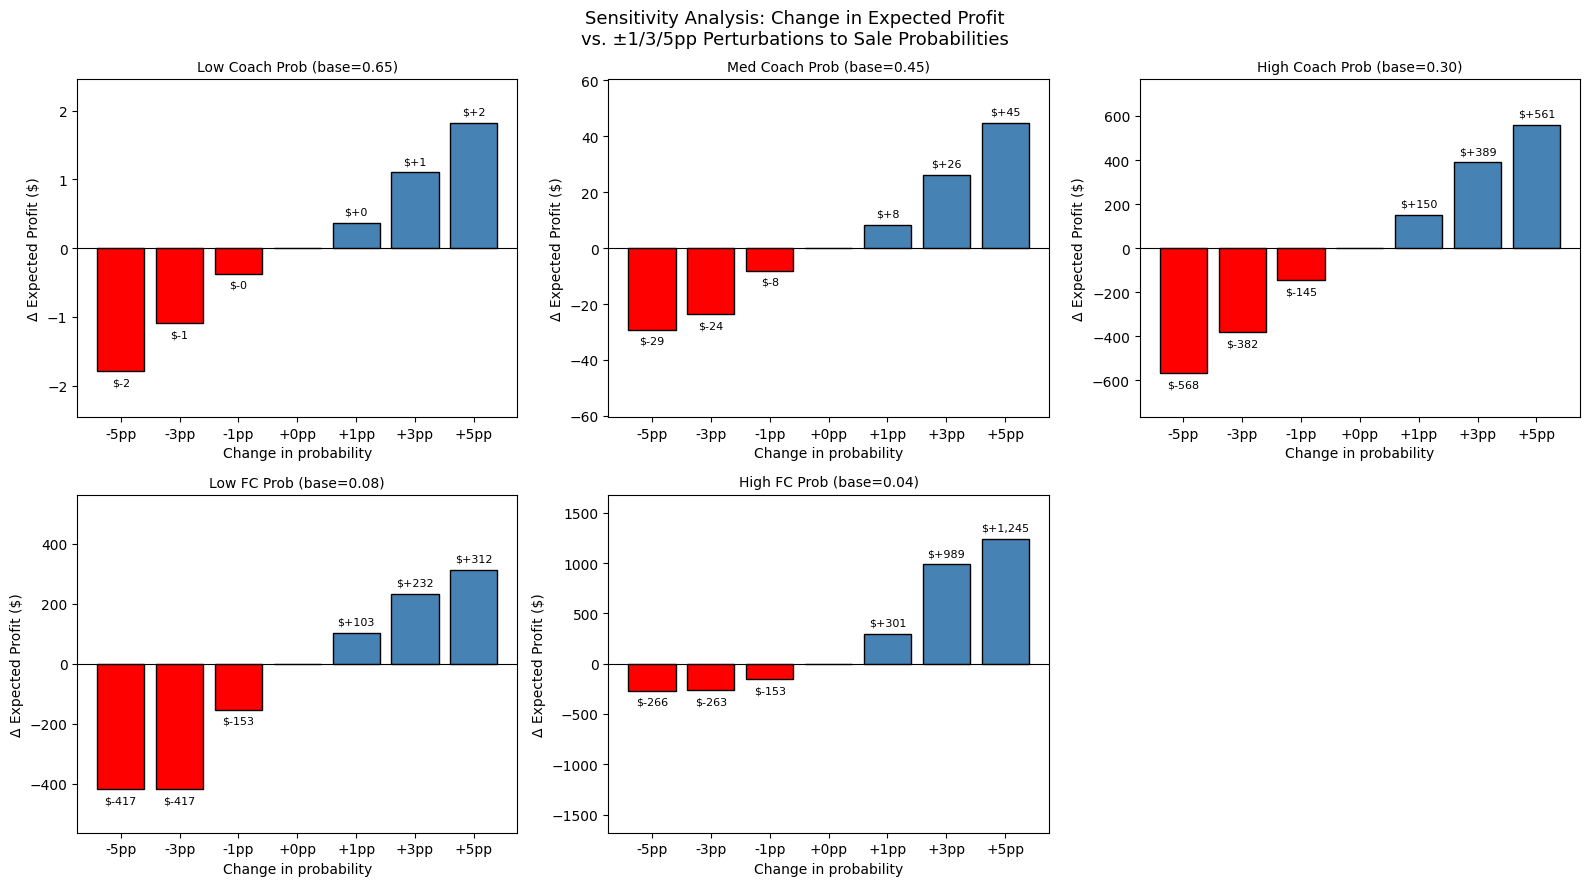

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

pct_labels = [f"{d*100:+.0f}pp" for d in perturbations]

for ax, (label, key) in zip(axes, prob_names):
    profits = sensitivity_results[label]
    changes = [p - baseline_profit for p in profits]
    colors  = ['red' if c < 0 else 'steelblue' for c in changes]
    bars = ax.bar(pct_labels, changes, color=colors, edgecolor='black')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Change in probability')
    ax.set_ylabel('Δ Expected Profit ($)')

    abs_max = max(abs(c) for c in changes) if any(changes) else 1
    pad = abs_max * 0.35  # uniform padding as fraction of data range
    ax.set_ylim(-abs_max - pad, abs_max + pad)

    for bar, val in zip(bars, changes):
        if val == 0:
            continue
        offset = abs_max * 0.05  # label offset as fraction of data range
        y_pos  = val + offset if val >= 0 else val - offset
        va     = 'bottom'    if val >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2,
                y_pos, f'${val:+,.0f}',
                ha='center', va=va, fontsize=8)

axes[-1].axis('off')
plt.suptitle('Sensitivity Analysis: Change in Expected Profit\n'
             'vs. ±1/3/5pp Perturbations to Sale Probabilities', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation

**Findings:**  
The sensitivity analysis reveals that expected profit is highly asymmetric in its response to different probability parameters. The most important finding is that the model is not uniformly robust - sensitivity varies dramatically depending on which probability is perturbed.  

- **High Coach Price Probability** (base = 0.30) is the single most sensitive parameter. A 5pp drop (to 0.25) costs $568 in expected profit, while a 5pp gain yields +$561. This makes economic sense: the $350 price point is the airline's primary revenue lever in the early booking window (days 0–150), when few tickets have been sold and the DP aggressively charges the high price. A small erosion in demand at this price point compounds over 365 days.

- **Low First-Class Probability** (base = 0.08) is the second most sensitive parameter, with a 5pp decrease causing a $417 loss. Notably, both the −5pp and −3pp perturbations yield identical profit ($41,759.97), suggesting a threshold effect - once the FC probability drops below a certain level, the DP's optimal response (switching to a different price or no-sale) is the same, creating a flat region in the profit surface.

- **High First-Class Probability** (base = 0.04) is highly asymmetric: a +5pp gain produces a +$1,245 improvement, but a −5pp loss only costs $266. This asymmetry reflects the fact that a doubling of the high FC sale probability (from 4% to 9%) dramatically increases first-class revenue over 365 days, while the downside is bounded since FC tickets are rarely sold at baseline anyway.

- **Low Coach Price Probability** (base = 0.65) is the least sensitive parameter despite being the most frequently triggered. A ±5pp shift moves profit by only ~$2. This is because the $300 price is the fallback option used near departure when seats remain unsold - at that stage, the marginal value of each additional seat is low and the DP has already captured most of its optimal revenue.

**Key Takeaway:**  
The airline should invest most heavily in accurately estimating demand at the high price points rather than the low ones. Mis-specifying the $350 coach or $425/$500 first-class demand probabilities by even 3pp can move expected profit by hundreds of dollars per flight. Across a fleet operating hundreds of routes, these errors compound significantly. The model is robust to uncertainty in low-price coach demand but fragile to uncertainty in premium-price demand.

---

## Part 5: Time-Varying (Seasonal) Demand

- On each day t (where t=0 is 365 days before departure and t=364 is the day before departure), multiply every sale probability by the factor (0.75 + t/730).
- At t=0:   factor = 0.75 + 0/730   ≈ 0.75  (low early demand)
- At t=182: factor = 0.75 + 182/730 ≈ 1.00  (baseline demand)
- At t=364: factor = 0.75 + 364/730 ≈ 1.25  (high late demand)
- This captures the common pattern that flights fill up faster as departure approaches.

In [58]:
def run_dp_seasonal(choices, ob_limit=30,
                    c_show=0.95, fc_show=0.97,
                    bump_fc=50, bump_off=425,
                    fc_boost=0.04):
    """
    DP with time-varying demand: each day's sale probability is
    multiplied by (0.75 + t/730), capped at 1.0.
    t=0 is 365 days before departure (low demand).
    t increases toward departure (higher demand).
    """
    max_c = coach_seats + ob_limit
    V = np.zeros((T + 1, max_c + 1, first_class_seats + 1))
    U = np.zeros((T + 1, max_c + 1, first_class_seats + 1), dtype=int)
 
    # Terminal condition (same as before — no sale possible, only costs)
    for c in range(max_c + 1):
        for f in range(first_class_seats + 1):
            cost_exp = 0
            p_c  = binom.pmf(range(c + 1), c, c_show)
            p_fc = binom.pmf(range(f + 1), f, fc_show)
            for i in range(c + 1):
                for j in range(f + 1):
                    p_ij = p_c[i] * p_fc[j]
                    overbooked = max(0, i - coach_seats)
                    fc_empty   = max(0, first_class_seats - j)
                    bumped_up  = min(overbooked, fc_empty)
                    bumped_off = overbooked - bumped_up
                    cost       = bumped_up * bump_fc + bumped_off * bump_off
                    cost_exp  += p_ij * cost
            V[T, c, f] = -cost_exp
 
    # Bellman equation with time-varying probabilities
    for t in reversed(range(T)):
        season_factor = min(1.0 / max(p for _, p, _, _ in choices if p > 0),
                            0.75 + t / 730)
        # Safer: compute factor independently; cap each prob at 1
        factor = 0.75 + t / 730
 
        for c in range(max_c + 1):
            for f in range(first_class_seats + 1):
                c_full  = (c == max_c)
                fc_full = (f == first_class_seats)
                if c_full and fc_full:
                    V[t, c, f] = discount * V[t + 1, c, f]
                    U[t, c, f] = 0
                    continue
                best_profit = -np.inf
                best_choice = 0
                for idx, (cp, cpr, fp, fpr) in enumerate(choices):
                    # Scale probabilities by seasonal factor, cap at 1
                    ps_c  = 0 if c_full  else min(1.0, cpr * factor)
                    ps_fc = 0 if fc_full else min(1.0, fpr * factor)
                    if fc_full and not c_full and cpr > 0:
                        # Boost applies after scaling, still cap at 1
                        ps_c = min(1.0, ps_c + fc_boost)
                    cn = min(c + 1, max_c)
                    fn = min(f + 1, first_class_seats)
                    today = ps_c * cp + ps_fc * fp
                    future = (
                        (1 - ps_c) * (1 - ps_fc) * V[t+1, c,  f ] +
                        ps_c       * (1 - ps_fc) * V[t+1, cn, f ] +
                        (1 - ps_c) * ps_fc        * V[t+1, c,  fn] +
                        ps_c       * ps_fc         * V[t+1, cn, fn]
                    )
                    profit = today + discount * future
                    if profit > best_profit:
                        best_profit = profit
                        best_choice = idx + 1
                V[t, c, f] = best_profit
                U[t, c, f] = best_choice
    return round(V[0, 0, 0], 2), V, U
 
 
print("Running Part 5 DP (seasonal demand)...")
seasonal_profit, V_seas, U_seas = run_dp_seasonal(BASE_CHOICES)
print(f"Seasonal demand expected profit: ${seasonal_profit:,.2f}")
print(f"Baseline (Part 3) expected profit: ${baseline_profit:,.2f}")
print(f"Difference: ${seasonal_profit - baseline_profit:+,.2f}")

Running Part 5 DP (seasonal demand)...
Seasonal demand expected profit: $41,863.83
Baseline (Part 3) expected profit: $42,177.14
Difference: $-313.31


- Plot 1: value function over time (seasonal vs flat)
- Plot 2: pricing policy under seasonal demand

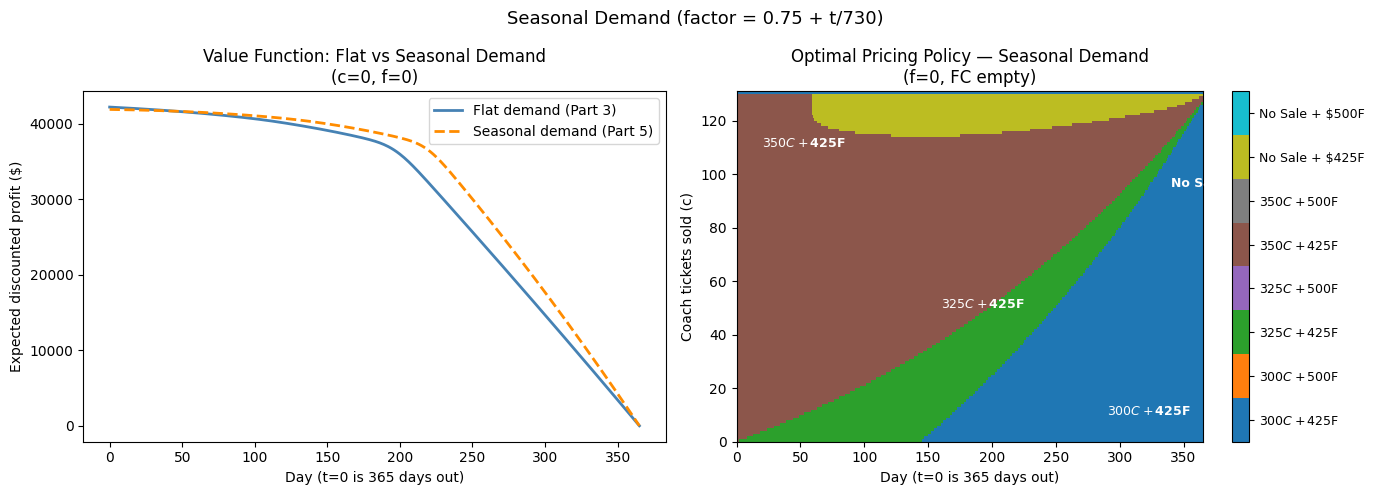

In [94]:
from matplotlib.colors import BoundaryNorm

choice_labels = [
    '$300C + $425F', '$300C + $500F',
    '$325C + $425F', '$325C + $500F',
    '$350C + $425F', '$350C + $500F',
    'No Sale + $425F', 'No Sale + $500F'
]

cmap_standard = plt.colormaps.get_cmap('tab10').resampled(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: value function comparison
axes[0].plot(range(T + 1), V_base[:, 0, 0], label='Flat demand (Part 3)',
             color='steelblue', linewidth=2)
axes[0].plot(range(T + 1), V_seas[:, 0, 0], label='Seasonal demand (Part 5)',
             color='darkorange', linestyle='--', linewidth=2)
axes[0].set_xlabel('Day (t=0 is 365 days out)')
axes[0].set_ylabel('Expected discounted profit ($)')
axes[0].set_title('Value Function: Flat vs Seasonal Demand\n(c=0, f=0)')
axes[0].legend()

# Right: pricing policy heatmap
im = axes[1].pcolormesh(U_seas[:T, :, 0].T, cmap=cmap_standard, vmin=0.5, vmax=8.5)
cbar = fig.colorbar(im, ax=axes[1], ticks=range(1, 9))
cbar.ax.set_yticklabels(choice_labels, fontsize=9)
axes[1].set_xlabel('Day (t=0 is 365 days out)')
axes[1].set_ylabel('Coach tickets sold (c)')
axes[1].set_title('Optimal Pricing Policy — Seasonal Demand\n(f=0, FC empty)')
axes[1].text(20,  110, '$350C + $425F', fontsize=9, color='white', fontweight='bold')
axes[1].text(160,  50, '$325C + $425F', fontsize=9, color='white', fontweight='bold')
axes[1].text(290,  10, '$300C + $425F', fontsize=9, color='white', fontweight='bold')
axes[1].text(340,  95, 'No Sale',        fontsize=9, color='white', fontweight='bold')

plt.suptitle('Seasonal Demand (factor = 0.75 + t/730)', fontsize=13)
plt.tight_layout()
plt.show()

Plot: effective sale probability over time for each coach price

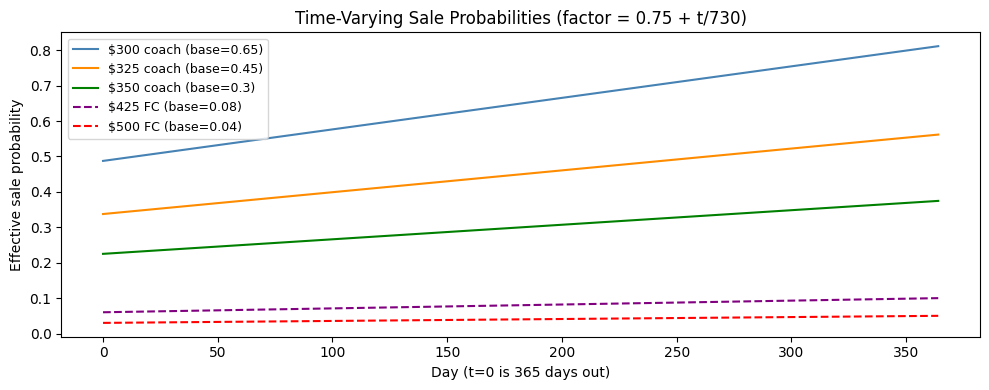

In [66]:
t_vals = np.arange(T)
factors = 0.75 + t_vals / 730
 
plt.figure(figsize=(10, 4))
plt.plot(t_vals, np.minimum(1.0, low_coach_prob  * factors), label=f'$300 coach (base={low_coach_prob})',  color='steelblue')
plt.plot(t_vals, np.minimum(1.0, med_coach_prob  * factors), label=f'$325 coach (base={med_coach_prob})',  color='darkorange')
plt.plot(t_vals, np.minimum(1.0, high_coach_prob * factors), label=f'$350 coach (base={high_coach_prob})', color='green')
plt.plot(t_vals, np.minimum(1.0, low_fc_prob     * factors), label=f'$425 FC (base={low_fc_prob})',    color='purple', linestyle='--')
plt.plot(t_vals, np.minimum(1.0, high_fc_prob    * factors), label=f'$500 FC (base={high_fc_prob})',   color='red',    linestyle='--')
plt.xlabel('Day (t=0 is 365 days out)')
plt.ylabel('Effective sale probability')
plt.title('Time-Varying Sale Probabilities (factor = 0.75 + t/730)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Interpretation

**Findings:**  
Introducing time-varying demand (factor = 0.75 + t/730) **reduces** expected discounted profit from **$42,177** (flat demand baseline) to **$41,864**, a decrease of **$313**. This may seem counterintuitive given that demand rises above the flat baseline in the second half of the booking window, but the result follows from the interaction between discounting and timing.  

The seasonal factor suppresses demand below the flat baseline for the first ~182 days (factor < 1.0), precisely the period when discounting penalizes revenue the least (early revenues are worth more in present value terms). Conversely, the demand boost in the final ~182 days (factor > 1.0) arrives when discount factors are largest, reducing the present value of that additional revenue. In short, **the timing of the demand increase is unfavorable from a discounting perspective** - the airline earns less early and more late.  

The pricing policy heatmap under seasonal demand shows a structural shift compared to the flat-demand case. The **no-sale region expands significantly in the early booking window** - when the seasonal factor is low, the DP correctly recognizes that selling cheap tickets now forfeits capacity for higher-value late-season buyers. This manifests as the large "No Sale" region visible at high ticket counts (c > 100) across nearly all days, and at moderate ticket counts in the first 50–60 days.  

The value function comparison plot confirms this: the seasonal demand curve lies below the flat demand curve throughout most of the booking horizon, only converging near departure when the seasonal factor approaches and exceeds 1.0. The steeper drop in the seasonal value function after day 200 reflects the compounding effect of having sold fewer tickets in the early window - the airline enters the high-demand late period with fewer seats already locked in at discounted prices.

**Key Takeaway:**  
Seasonal demand patterns actually hurt profitability under a discount rate of 17% annually because they shift revenue toward the future. Airlines operating under high discount rates should be particularly aggressive about early-window pricing to capture present-value-rich revenue, even if this means accepting lower prices early. The no-sale option is especially valuable under seasonal demand - it allows the airline to deliberately suppress early sales and preserve capacity for the late-demand surge, partially offsetting the discount-rate penalty.

---

## Part 6: Forward Simulation of the Optimal Policy

- We use the Part 3 optimal policy (V_base, U_base — OB=30, no-sale option, flat demand) and also the Part 5 seasonal policy (V_seas, U_seas) and simulate each forward many times.
- We track:
    - How often is coach overbooked (i.e., > 100 passengers show up)?
    - How often are passengers kicked off the plane?
    - Average overbooking cost per flight
    - Distribution (volatility) of discounted profits

In [68]:
def simulate_forward(U_policy, max_c, n_sims=10_000,
                     c_show=0.95, fc_show=0.97,
                     bump_fc=50, bump_off=425,
                     fc_boost=0.04,
                     seasonal=False):
    """
    Simulate n_sims flights forward in time using the given policy U.
    On each day, use U[t, c, f] to pick the price combo, then
    draw a Bernoulli sale for coach and first class.
    On departure day (t=T), draw show-up counts from Binomial.
 
    Returns arrays of per-flight statistics.
    """
    rng = np.random.default_rng(42)
 
    coach_overbooked_count   = np.zeros(n_sims, dtype=int)   # # passengers without seat
    kicked_off_count         = np.zeros(n_sims, dtype=int)   # # bumped off plane entirely
    bumped_to_fc_count       = np.zeros(n_sims, dtype=int)   # # bumped up to FC
    overbooking_cost         = np.zeros(n_sims)              # total $ overbooking cost
    total_revenue            = np.zeros(n_sims)              # undiscounted ticket revenue
    discounted_profit        = np.zeros(n_sims)              # discounted revenue - discounted cost
 
    for sim in range(n_sims):
        c = 0   # coach tickets sold so far
        f = 0   # first class tickets sold so far
        rev = 0.0
        disc_rev = 0.0
 
        for t in range(T):
            choice_idx = U_policy[t, c, f]  # 0 = can't sell, 1-8 = price combo index
            if choice_idx == 0:
                continue  # both full or no sale optimal
 
            # Decode choice (1-indexed into BASE_CHOICES)
            cp, cpr_base, fp, fpr_base = BASE_CHOICES[choice_idx - 1]
 
            # Apply seasonal factor if requested
            factor = (0.75 + t / 730) if seasonal else 1.0
            cpr = min(1.0, cpr_base * factor)
            fpr = min(1.0, fpr_base * factor)
 
            # Apply first-class sold-out boost
            fc_full = (f == first_class_seats)
            c_full  = (c == max_c)
            if fc_full and not c_full and cpr_base > 0:
                cpr = min(1.0, cpr + fc_boost)
 
            # Simulate today's sales
            if not c_full and cp > 0:
                sold_coach = rng.random() < cpr
                if sold_coach and c < max_c:
                    c += 1
                    day_discount = discount ** t
                    rev      += cp
                    disc_rev += cp * day_discount
 
            if not fc_full and fp > 0:
                sold_fc = rng.random() < fpr
                if sold_fc and f < first_class_seats:
                    f += 1
                    day_discount = discount ** t
                    rev      += fp
                    disc_rev += fp * day_discount
 
        # --- Departure day: draw show-up counts ---
        showed_coach = rng.binomial(c, c_show)
        showed_fc    = rng.binomial(f, fc_show)
 
        overbooked  = max(0, showed_coach - coach_seats)
        fc_empty    = max(0, first_class_seats - showed_fc)
        bumped_up   = min(overbooked, fc_empty)
        bumped_off  = overbooked - bumped_up
        cost        = bumped_up * bump_fc + bumped_off * bump_off
 
        # Discounted cost (at departure, t=T)
        disc_cost = cost * (discount ** T)
 
        coach_overbooked_count[sim] = overbooked
        kicked_off_count[sim]       = bumped_off
        bumped_to_fc_count[sim]     = bumped_up
        overbooking_cost[sim]       = cost
        total_revenue[sim]          = rev
        discounted_profit[sim]      = disc_rev - disc_cost
 
    return {
        'coach_overbooked':  coach_overbooked_count,
        'kicked_off':        kicked_off_count,
        'bumped_to_fc':      bumped_to_fc_count,
        'ob_cost':           overbooking_cost,
        'revenue':           total_revenue,
        'disc_profit':       discounted_profit,
    }
 
 
N_SIMS = 10_000
print(f"Simulating {N_SIMS:,} flights for Part 3 policy (flat demand)...")
res_flat = simulate_forward(U_base, max_coach_tix_sold, n_sims=N_SIMS, seasonal=False)
 
print(f"Simulating {N_SIMS:,} flights for Part 5 policy (seasonal demand)...")
res_seas = simulate_forward(U_seas, max_coach_tix_sold, n_sims=N_SIMS, seasonal=True)

Simulating 10,000 flights for Part 3 policy (flat demand)...
Simulating 10,000 flights for Part 5 policy (seasonal demand)...


In [69]:
def print_stats(results, label):
    ob  = results['coach_overbooked']
    ko  = results['kicked_off']
    bfc = results['bumped_to_fc']
    obc = results['ob_cost']
    dp  = results['disc_profit']
 
    print(f"\n--- {label} ---")
    print(f"  Coach overbooked (>0 passengers without seat): {(ob > 0).mean()*100:.1f}% of flights")
    print(f"  Average passengers overbooked (when >0):       {ob[ob>0].mean():.2f} people")
    print(f"  Passengers kicked off plane (>0):              {(ko > 0).mean()*100:.1f}% of flights")
    print(f"  Average kicked off (when >0):                  {ko[ko>0].mean():.2f} people")
    print(f"  Passengers bumped to FC (>0):                  {(bfc>0).mean()*100:.1f}% of flights")
    print(f"  Average bumped to FC (when >0):                {bfc[bfc>0].mean():.2f} people")
    print(f"  Average overbooking cost per flight:           ${obc.mean():,.2f}")
    print(f"  Std dev of overbooking cost:                   ${obc.std():,.2f}")
    print(f"  Average discounted profit:                     ${dp.mean():,.2f}")
    print(f"  Std dev (volatility) of discounted profit:     ${dp.std():,.2f}")
    print(f"  5th percentile discounted profit:              ${np.percentile(dp, 5):,.2f}")
    print(f"  95th percentile discounted profit:             ${np.percentile(dp, 95):,.2f}")
 
print_stats(res_flat, "Part 3 Policy — Flat Demand Simulation")
print_stats(res_seas, "Part 5 Policy — Seasonal Demand Simulation")


--- Part 3 Policy — Flat Demand Simulation ---
  Coach overbooked (>0 passengers without seat): 85.4% of flights
  Average passengers overbooked (when >0):       3.98 people
  Passengers kicked off plane (>0):              74.8% of flights
  Average kicked off (when >0):                  3.37 people
  Passengers bumped to FC (>0):                  53.3% of flights
  Average bumped to FC (when >0):                1.64 people
  Average overbooking cost per flight:           $1,115.02
  Std dev of overbooking cost:                   $890.53
  Average discounted profit:                     $42,178.91
  Std dev (volatility) of discounted profit:     $905.88
  5th percentile discounted profit:              $40,694.85
  95th percentile discounted profit:             $43,677.11

--- Part 5 Policy — Seasonal Demand Simulation ---
  Coach overbooked (>0 passengers without seat): 85.5% of flights
  Average passengers overbooked (when >0):       3.90 people
  Passengers kicked off plane (>0):    

Plot 1: Distribution of discounted profit

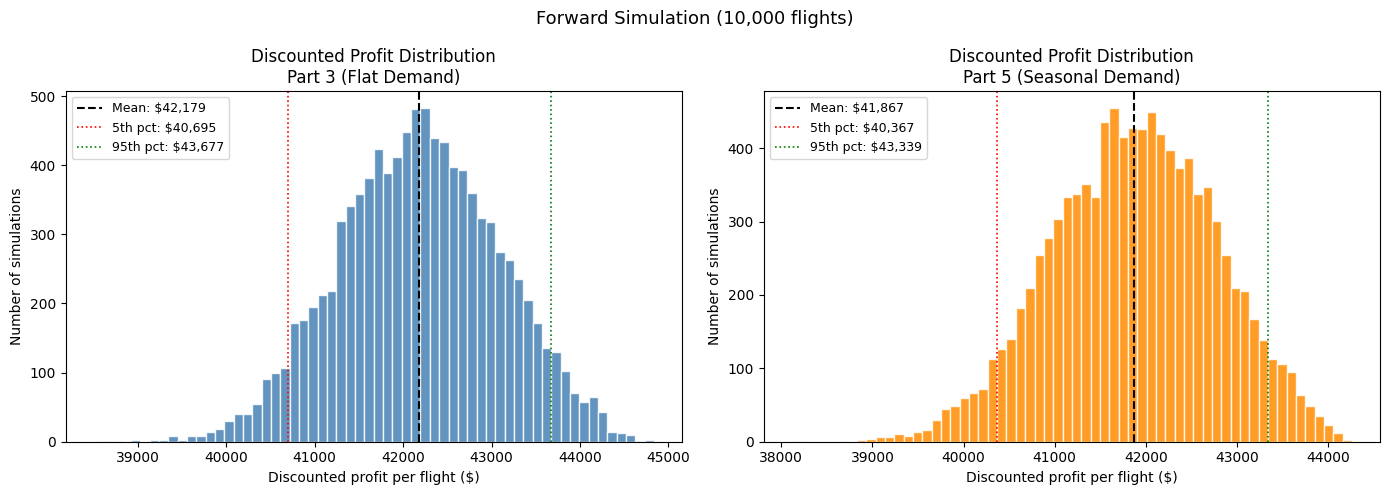

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, results, label, color in zip(
    axes,
    [res_flat, res_seas],
    ['Part 3 (Flat Demand)', 'Part 5 (Seasonal Demand)'],
    ['steelblue', 'darkorange']
):
    dp = results['disc_profit']
    ax.hist(dp, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(dp.mean(),             color='black',  linestyle='--', linewidth=1.5,
               label=f'Mean: ${dp.mean():,.0f}')
    ax.axvline(np.percentile(dp, 5),  color='red',    linestyle=':',  linewidth=1.2,
               label=f'5th pct: ${np.percentile(dp,5):,.0f}')
    ax.axvline(np.percentile(dp, 95), color='green',  linestyle=':',  linewidth=1.2,
               label=f'95th pct: ${np.percentile(dp,95):,.0f}')
    ax.set_title(f'Discounted Profit Distribution\n{label}')
    ax.set_xlabel('Discounted profit per flight ($)')
    ax.set_ylabel('Number of simulations')
    ax.legend(fontsize=9)
 
plt.suptitle(f'Forward Simulation ({N_SIMS:,} flights)', fontsize=13)
plt.tight_layout()
plt.show()

Plot 2: Overbooking cost distribution

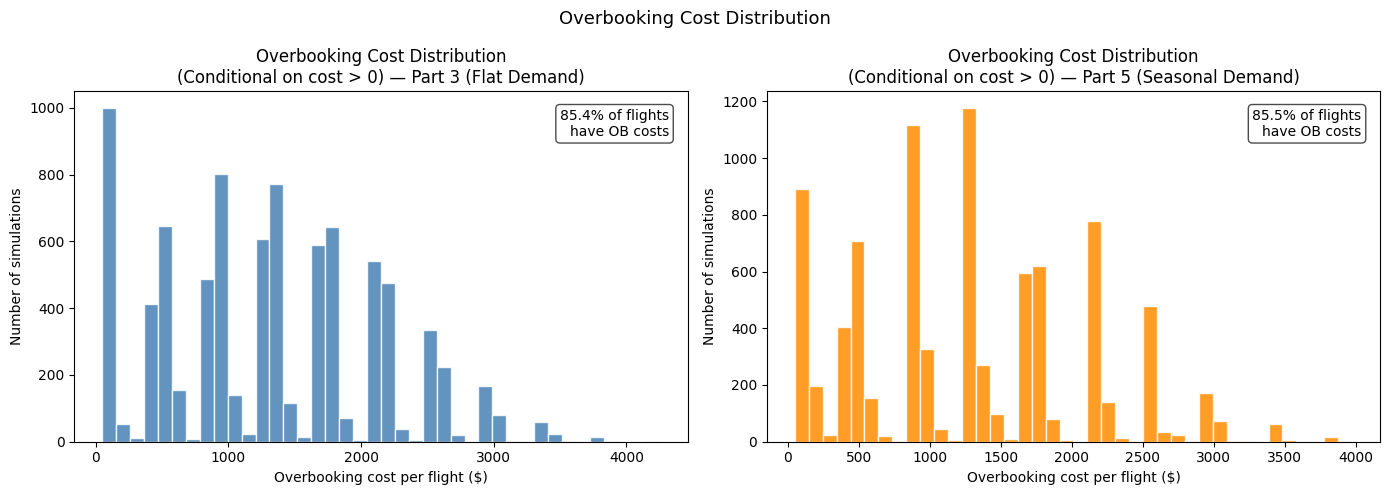

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, results, label, color in zip(
    axes,
    [res_flat, res_seas],
    ['Part 3 (Flat Demand)', 'Part 5 (Seasonal Demand)'],
    ['steelblue', 'darkorange']
):
    ob_costs = results['ob_cost']
    ax.hist(ob_costs[ob_costs > 0], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Overbooking Cost Distribution\n(Conditional on cost > 0) — {label}')
    ax.set_xlabel('Overbooking cost per flight ($)')
    ax.set_ylabel('Number of simulations')
    pct_ob = (ob_costs > 0).mean() * 100
    ax.text(0.97, 0.95, f'{pct_ob:.1f}% of flights\nhave OB costs',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
 
plt.suptitle('Overbooking Cost Distribution', fontsize=13)
plt.tight_layout()
plt.show()

Plot 3: How often is coach overbooked vs. kicked off?

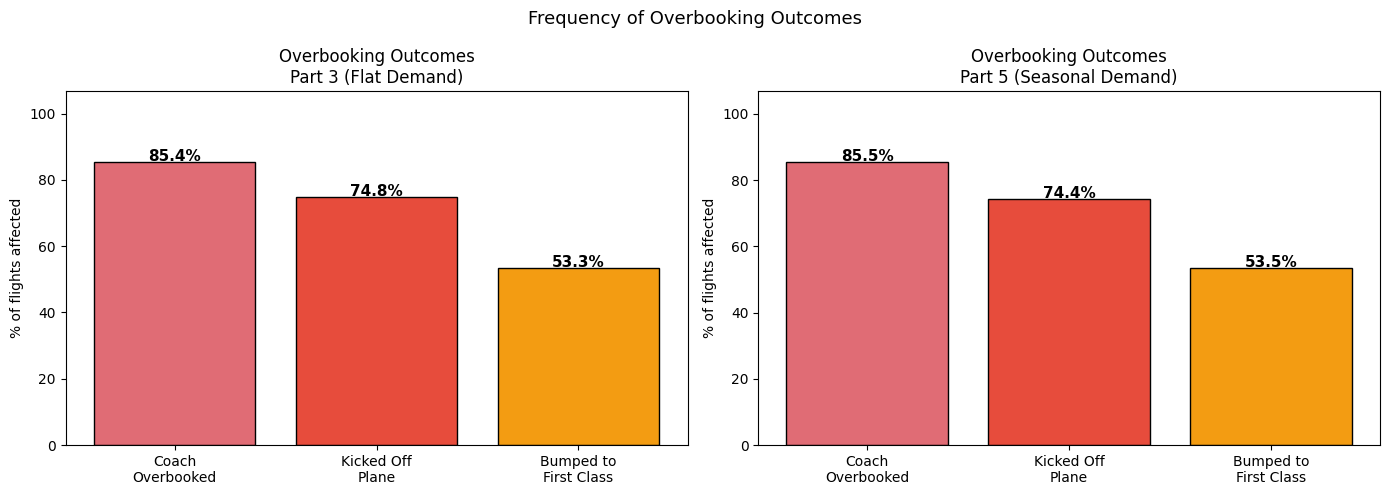

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, results, label in zip(
    axes,
    [res_flat, res_seas],
    ['Part 3 (Flat Demand)', 'Part 5 (Seasonal Demand)']
):
    ob  = results['coach_overbooked']
    ko  = results['kicked_off']
    bfc = results['bumped_to_fc']
 
    categories = ['Coach\nOverbooked', 'Kicked Off\nPlane', 'Bumped to\nFirst Class']
    pcts = [
        (ob  > 0).mean() * 100,
        (ko  > 0).mean() * 100,
        (bfc > 0).mean() * 100,
    ]
    bars = ax.bar(categories, pcts, color=['#e06c75', '#e74c3c', '#f39c12'], edgecolor='black')
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(pcts) * 1.25)
    ax.set_ylabel('% of flights affected')
    ax.set_title(f'Overbooking Outcomes\n{label}')
 
plt.suptitle('Frequency of Overbooking Outcomes', fontsize=13)
plt.tight_layout()
plt.show()

Plot 4: Revenue vs overbooking cost scatter

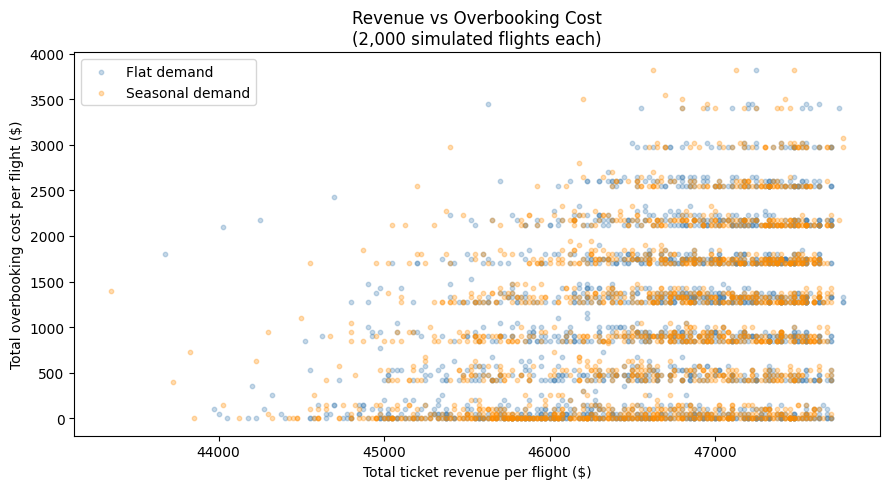

In [73]:
fig, ax = plt.subplots(figsize=(9, 5))
sample = np.random.choice(N_SIMS, 2000, replace=False)
ax.scatter(res_flat['revenue'][sample], res_flat['ob_cost'][sample],
           alpha=0.3, s=10, color='steelblue', label='Flat demand')
ax.scatter(res_seas['revenue'][sample], res_seas['ob_cost'][sample],
           alpha=0.3, s=10, color='darkorange', label='Seasonal demand')
ax.set_xlabel('Total ticket revenue per flight ($)')
ax.set_ylabel('Total overbooking cost per flight ($)')
ax.set_title('Revenue vs Overbooking Cost\n(2,000 simulated flights each)')
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

**Findings:**  
Ten thousand forward simulations of both the flat-demand (Part 3) and seasonal-demand (Part 5) policies reveal a consistent and important operational reality: **overbooking under the optimal DP policy is frequent and material**.  

**Overbooking frequency is high by design**. Under both policies, coach is overbooked (more than 100 passengers show up) in approximately **85% of flights**. This is not a flaw - it is the intended consequence of the OB=30 ceiling policy. With an average of ~109 tickets sold and a 95% show-up rate, the expected number of coach arrivals is ~103–104, consistently above the 100-seat capacity. The DP has already priced in these costs in the Bellman equation; the simulation confirms the DP's arithmetic.  

**Passengers are kicked off the plane on 74–75% of flights**, averaging 3.3–3.4 people per affected flight. This is the more consequential metric from a customer relations standpoint. Bumping occurs when overbooked coach passengers exceed available first-class seats, which happens frequently since first-class is also often close to full under the optimal policy. The average overbooking cost per flight is **~$1,100**, with a standard deviation of ~$890, indicating substantial flight-to-flight variability in this cost.  

**Profit volatility is moderate but meaningful**. The 90th-percentile range (5th to 95th percentile) spans approximately **$3,000** ($40,695 to $43,677 for the flat policy). The standard deviation of ~$906 represents roughly 2.1% of mean profit - acceptable volatility for an operation of this scale, but notable because the downside tail is driven almost entirely by overbooking cost variability rather than revenue variability. The revenue vs. overbooking cost scatter plot confirms this: high-revenue flights cluster at high overbooking costs, because both result from the same underlying cause - many tickets sold and high show-up realizations.  

**Comparing the two policies:**  
The flat and seasonal simulations are nearly identical in overbooking frequency and passenger impact statistics, but diverge meaningfully in profit. The flat policy delivers **~$311 more in average discounted profit** ($42,179 vs $41,867), consistent with the DP-computed difference of $313. The seasonal policy slightly reduces overbooking costs ($1,084 vs $1,115 average) because its expanded no-sale region prevents a small number of marginal late-season sales that would otherwise push ticket counts into the highest overbooking range - but this cost saving is more than offset by the lost revenue from those unsold tickets.  

**Notably absent from this comparison** is the Part 2 hard-cap policy (OB=9), which would be expected to show substantially lower overbooking frequency and cost, at the expense of ~$6 in expected profit versus the flexible no-sale policy. Future simulation work should include this comparison to give management a full picture of the overbooking cost–profit tradeoff across all three policy types.  

**Key Takeaway:**  
The optimal overbooking policy is profitable in expectation but operationally aggressive - three in four flights will require bumping at least one passenger off the plane entirely. Management must weigh this against reputational and goodwill costs not captured in the model. If the true cost of bumping a passenger (including brand damage and future lost bookings) exceeds the $425 voucher currently modeled, the optimal overbooking limit would shift downward. A conservative estimate of even $50 in additional implicit cost per bump would meaningfully change the optimal policy, and this constitutes an important modeling limitation.  

---

### Final Summary table

In [ ]:
print("\n\n===== FINAL SUMMARY: PARTS 1-6 =====")
print(f"{'Policy':<40} {'Expected Profit':>18}")
print("-" * 60)
print(f"{'Part 1 — Hard Cap OB=5':<40} {'$41,909.75':>18}")
print(f"{'Part 2 — Hard Cap OB=9 (optimal)':<40} {'$42,171.35':>18}")
print(f"{'Part 3 — Flexible No-Sale OB=30':<40} {'$42,177.14':>18}")
print(f"{'Part 5 — Seasonal Demand (OB=30)':<48} ${seasonal_profit:,.2f}")
print()
print("Forward simulation (10,000 flights):")
for label, results in [('Part 3 (flat)', res_flat), ('Part 5 (seasonal)', res_seas)]:
    dp = results['disc_profit']
    ob = results['coach_overbooked']
    ko = results['kicked_off']
    obc = results['ob_cost']
    print(f"\n  {label}:")
    print(f"    Avg discounted profit:  ${dp.mean():,.2f}  (std: ${dp.std():,.2f})")
    print(f"    Coach OB rate:          {(ob>0).mean()*100:>9.1f}%")
    print(f"    Passengers kicked off:  {(ko>0).mean()*100:>9.1f}% of flights")
    print(f"    Avg OB cost/flight:     ${obc.mean():,.2f}  (std: ${obc.std():,.2f})")



===== FINAL SUMMARY: PARTS 1-6 =====
Policy                                      Expected Profit
------------------------------------------------------------
Part 1 — Hard Cap OB=5                           $41,909.75
Part 2 — Hard Cap OB=9 (optimal)                 $42,171.35
Part 3 — Flexible No-Sale OB=30                  $42,177.14
Part 5 — Seasonal Demand (OB=30)                 $41,863.83

Forward simulation (10,000 flights):

  Part 3 (flat):
    Avg discounted profit:  $42,178.91  (std: $905.88)
    Coach OB rate:               85.4%
    Passengers kicked off:       74.8% of flights
    Avg OB cost/flight:     $1,115.02  (std: $890.53)

  Part 5 (seasonal):
    Avg discounted profit:  $41,867.43  (std: $900.89)
    Coach OB rate:               85.5%
    Passengers kicked off:       74.4% of flights
    Avg OB cost/flight:     $1,083.99  (std: $876.12)


---

End of Jupyter Notebook.